<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# **Desafio, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/may_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.

# Imports

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
import pickle
import os

# Data


### Load

In [2]:
# Eng-Spa translations.
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("./spa-eng/spa.txt") as f:
    lines = f.read().split("\n")[:-1]

In [47]:
# Max number of sentences considered (keep small due to RAM)
MAX_NUM_SENTENCES = 30000
# Set seed
np.random.seed(42)
np.random.shuffle(lines)

In [48]:
# Load data into lists.
input_sentences, output_sentences, output_sentences_inputs = [], [], []

# Loop until max number of sentences is reached. Append end of sentence
# and start of sentence tokens to output sentences.
for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Sentences loaded: {len(input_sentences)}")

Sentences loaded: 30000


In [49]:
# Example
print(input_sentences[0])
print(output_sentences[0])
print(output_sentences_inputs[0])

Do not forget to meet me at the station.
No te olvides de encontrarte conmigo en la estación. <eos>
<sos> No te olvides de encontrarte conmigo en la estación.


### Tokenize

In [50]:
# Max vocabulary size (for each language, most frequent words are used)
MAX_VOCAB_SIZE = 15000

# Tokenizer - inputs
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

# Tokenizer - outputs
output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)

output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

max_input_len = 20
max_out_len   = 22

print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")
print(f"max_input_len={max_input_len}  max_out_len={max_out_len}")

Vocabulario EN: 8103 | ES: 13942
max_input_len=20  max_out_len=22


In [51]:
# Padding for sequences
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

In [52]:
# Example.
print(encoder_input_sequences[0])
print(decoder_input_sequences[0])
print(decoder_output_sequences[0])

[  0   0   0   0   0   0   0   0   0   0   0  14  32 454   3 404  15  35
   1 391]
[6943    5   27  969    2 2733  210    9    7  299    0    0    0    0
    0    0    0    0    0    0    0    0]
[   5   27  969    2 2733  210    9    7  299    1    0    0    0    0
    0    0    0    0    0    0    0    0]


### TF Dataset

In [53]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):
    """Make a tensorflow dataset for (enc_in, dec_in), dec_out batches"""
    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes) # shape (max_out_len, num_classes)
        # Returns (encoder_in, decoder_in), decoder_out
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [54]:
# Build train/valid datasets.
BATCH_SIZE = 64
val_split  = 0.15
split_idx  = int(len(encoder_input_sequences) * (1 - val_split))

# Split is done by index.
train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)

### GloVe embeddings

For encoder embedding layer

In [11]:
# Download embeddings
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Trying gloveembedding.pkl download...")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} "
                  f"'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("Downloaded file is not a valid pickle.")
    print("Download finished.")
else:
    print("gloveembedding.pkl is already available.")

Trying gloveembedding.pkl download...


Downloading...
From (original): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94
From (redirected): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&confirm=t&uuid=f2615b2c-c69a-4d5a-996d-d482302ff847
To: /content/gloveembedding.pkl
100%|██████████| 525M/525M [00:08<00:00, 65.4MB/s]

Download finished.


In [12]:
def load_glove_embeddings(pkl_path):
    """Load GloVe embeddings."""
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx

In [13]:
def get_word_embedding(word, embeddings, word2idx, n_features=50):
    """Return embedding, if word exists. Else return zeros."""
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)

In [14]:
def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove,
                            nb_words, embed_dim=50):
    """Build embedding matrix."""
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

In [55]:
# Get embeddings.
EMBED_DIM = 50
nb_words  = min(MAX_VOCAB_SIZE, len(word2idx_inputs))

glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)
print(f"Null embeddings: {np.sum(np.sum(embedding_matrix**2, axis=1) == 0)}")

Null embeddings: 382


# Model (Seq2Seq Autoencoder)

In [76]:
# Number of units on the LSTM layer. (We'll try both 256 and 512.)
n_units = 512#256

In [40]:
def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units):
    """Function to build encoder. It returns
    (encoder_inputs, encoder_states, encoder_emb_layer, encoder_lstm_layer)
    to reuse them in the inference model.
    """
    # Inputs
    enc_inputs   = Input(shape=(max_input_len,), name='encoder_inputs')
    # Embeddings (GloVe - not trainable)
    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    # Dropout
    enc_emb = Dropout(0.3, name='encoder_dropout')(enc_emb_layer(enc_inputs))
    # LSTM layer.
    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer

In [41]:
def build_decoder(num_words_output, max_out_len, n_units, encoder_states):
    """Function to build decoder. It returns
    (decoder_inputs, decoder_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer)
    to reuse them in the inference model.
    """
    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        name='decoder_embedding'
    )
    dec_emb = Dropout(0.3, name='decoder_dropout')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm')
    dec_out, _, _  = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out         = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

In [77]:
# Build encoder and decoder.
enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
    nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units
)
dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
    num_words_output, max_out_len, n_units, enc_states
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [78]:
# Model as autoencoder.
model = Model([enc_inputs, dec_inputs], dec_outputs)

In [79]:
# Callbacks.
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)

In [80]:
# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

### Training (256)

In [62]:
hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=150,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/150
399/399 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.7231 - loss: 2.1745 - val_accuracy: 0.7448 - val_loss: 1.7895 - learning_rate: 0.0010
Epoch 2/150
399/399 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.7515 - loss: 1.6855 - val_accuracy: 0.7609 - val_loss: 1.6072 - learning_rate: 0.0010
Epoch 3/150
399/399 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.7667 - loss: 1.4925 - val_accuracy: 0.7757 - val_loss: 1.4586 - learning_rate: 0.0010
Epoch 4/150
399/399 ━━━━━━━━━━━━━━━━━━━━ 82s 205ms/step - accuracy: 0.7803 - loss: 1.3328 - val_accuracy: 0.7870 - val_loss: 1.3535 - learning_rate: 0.0010
Epoch 5/150
399/399 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.7914 - loss: 1.2070 - val_accuracy: 0.7944 - val_loss: 1.2841 - learning_rate: 0.0010
Epoch 6/150
399/399 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - accuracy: 0.7999 - loss: 1.1031 - val_accuracy: 0.8007 - val_loss: 1.2322 - learning_rate: 0.0010
Epoch 7/150
399/399 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accura

### Accuracy vs Epoch (256)

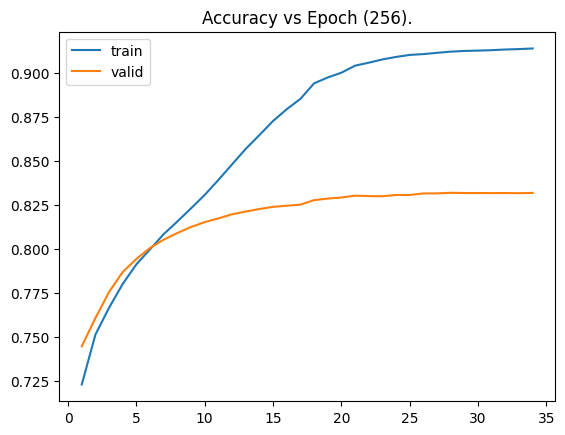

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

epoch_count = range(1, len(hist.history['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=hist.history['accuracy'],     label='train')
sns.lineplot(x=epoch_count, y=hist.history['val_accuracy'], label='valid')
plt.title("Accuracy vs Epoch (256).")
plt.show()

### Training (512)

In [81]:
hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=150,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/150
    399/Unknown 51s 120ms/step - accuracy: 0.7017 - loss: 2.6191

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


399/399 ━━━━━━━━━━━━━━━━━━━━ 57s 135ms/step - accuracy: 0.7275 - loss: 2.0367 - val_accuracy: 0.7484 - val_loss: 1.7409 - learning_rate: 0.0010
Epoch 2/150
399/399 ━━━━━━━━━━━━━━━━━━━━ 54s 135ms/step - accuracy: 0.7569 - loss: 1.6030 - val_accuracy: 0.7696 - val_loss: 1.5199 - learning_rate: 0.0010
Epoch 3/150
399/399 ━━━━━━━━━━━━━━━━━━━━ 55s 138ms/step - accuracy: 0.7772 - loss: 1.3700 - val_accuracy: 0.7864 - val_loss: 1.3576 - learning_rate: 0.0010
Epoch 4/150
399/399 ━━━━━━━━━━━━━━━━━━━━ 56s 140ms/step - accuracy: 0.7931 - loss: 1.1760 - val_accuracy: 0.7981 - val_loss: 1.2569 - learning_rate: 0.0010
Epoch 5/150
399/399 ━━━━━━━━━━━━━━━━━━━━ 56s 140ms/step - accuracy: 0.8071 - loss: 1.0140 - val_accuracy: 0.8062 - val_loss: 1.1882 - learning_rate: 0.0010
Epoch 6/150
399/399 ━━━━━━━━━━━━━━━━━━━━ 57s 142ms/step - accuracy: 0.8213 - loss: 0.8737 - val_accuracy: 0.8128 - val_loss: 1.1451 - learning_rate: 0.0010
Epoch 7/150
399/399 ━━━━━━━━━━━━━━━━━━━━ 56s 141ms/step - accuracy: 0.8367 -

### Accuracy vs Epoch (512)

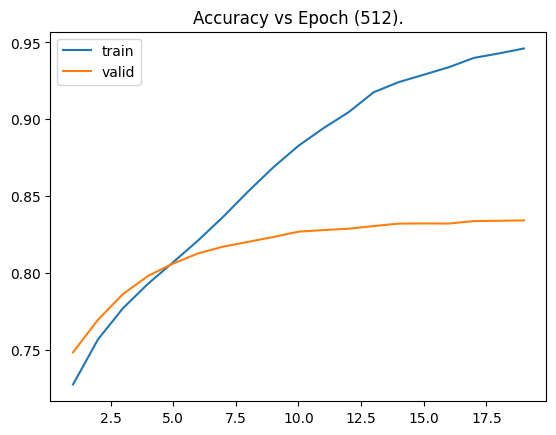

In [82]:
epoch_count = range(1, len(hist.history['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=hist.history['accuracy'],     label='train')
sns.lineplot(x=epoch_count, y=hist.history['val_accuracy'], label='valid')
plt.title("Accuracy vs Epoch (512).")
plt.show()

### Comparison (only training)

We see that increasing the number of units from 256 to 512 didn't particularly enhance our architecture's performance.

Valid (best epoch):
- 256 units: val_accuracy: 0.8318 | val_loss: 1.0896
- 512 units: val_accuracy: 0.8321 | val_loss: 1.0762

This clearly shows that both models have performed equally on the validation dataset, despite one model doubling the number of units of the other.

Also, both models show overfitting.

Train (best epoch):
- 256 units: accuracy: 0.9125 | loss: 0.3768
- 512 units: accuracy: 0.9242 | loss: 0.3228

The valid loss is around 3 times higher than the train loss, which is an indicator that there's overfitting. We also see this from the graphs, valid accuracy plateaus a lot earlier than when the early stop triggered, so perhaps a more agressive scheduler should've been used.

That said, the 512 model took around half the epochs to train than the 256 model, with epoch time being increased by around 20% only, so it had a shorter training time.

# Inference

In [83]:
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units):
    """Inference encoder. Uses trained weights."""
    enc_emb = enc_emb_layer(enc_inputs)
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return Model(enc_inputs, [state_h, state_c])


def build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):
    """Inference decoder (token by token). Uses trained weights."""
    dec_input_single = Input(shape=(1,), name='dec_input_single')
    dec_state_h_in   = Input(shape=(n_units,), name='dec_state_h')
    dec_state_c_in   = Input(shape=(n_units,), name='dec_state_c')

    dec_emb_single = dec_emb_layer(dec_input_single)
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single,
        initial_state=[dec_state_h_in, dec_state_c_in]
    )
    dec_out = dec_dense_layer(dec_out)

    return Model(
        [dec_input_single, dec_state_h_in, dec_state_c_in],
        [dec_out, h_out, c_out]
    )

# Build models
encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units)
decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)

In [26]:
def translate(text, method='gs', bw=3):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    if method == 'gs':
        return translate_sentence(seq)
    return translate_sentence_beam(seq, bw)

In [84]:
idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

In [28]:
# Greedy search
def translate_sentence(input_seq):
    # Initial encoder states
    h, c = encoder_model.predict(input_seq, verbose=0)
    target_seq      = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    # Greedy search
    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict(
            [target_seq, h, c], verbose=0
        )
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)

In [29]:
# Beam search
def translate_sentence_beam(input_seq, beam_width=3):
    # Initial encoder states
    h, c = encoder_model.predict(input_seq, verbose=0)
    eos = word2idx_outputs['<eos>']
    sos = word2idx_outputs['<sos>']

    # Initialize the beam, null log-probability for <sos> token
    # beam list: (cumulative_log_probability, sequence_list, state_h, state_c)
    beam = [(0.0, [sos], h, c)]

    for _ in range(max_out_len):
        candidates = []
        all_completed = True

        # Explore next step
        for log_prob, seq, h_state, c_state in beam:
            # If a sequence already hit <eos>, continue
            if seq[-1] == eos:
                candidates.append((log_prob, seq, h_state, c_state))
                continue

            all_completed = False

            # Input for decoder
            target_seq = np.zeros((1, 1))
            target_seq[0, 0] = seq[-1]

            # Predict next token probabilities
            output_tokens, next_h, next_c = decoder_model.predict(
                [target_seq, h_state, c_state], verbose=0
            )

            # probabilities to log-probabilities
            probs = output_tokens[0, 0, :] # shape (1, 1, vocab_size)
            log_probs = np.log(probs + 1e-10)

            # Get the top candidates
            top_indices = np.argsort(log_probs)[-beam_width:]

            for idx in top_indices:
                # Add the new token's log probability to the running total
                new_log_prob = log_prob + log_probs[idx]
                new_seq = seq + [idx]
                candidates.append((new_log_prob, new_seq, next_h, next_c))

        # If every path has hit <eos>, stop
        if all_completed:
            break

        # Sort candidates by highest log-prob and keep the top ones
        candidates.sort(key=lambda x: x[0], reverse=True)
        beam = candidates[:beam_width]

    # Get the best sequence from our final beam
    best_log_prob, best_seq, _, _ = beam[0]

    # Decode ids to words (skip <sos> and <eos>)
    output_sentence = [
        idx2word_target[idx] for idx in best_seq
        if idx != sos and idx != eos and idx > 0
    ]

    return ' '.join(output_sentence)

In [68]:
# Indices from dataset:
np.random.randint(len(input_sentences), size=5)

array([14001,  7675,  8994, 12915, 11718])

In [85]:
ds_idx = np.array([14001,  7675,  8994, 12915, 11718])

In [86]:
test_sentences = ["It is raining today.",
                  "The white cat is sleeping.",
                  "Are you happy?",
                  "I want you to go.",
                  "He doesn't have a car.",
                  "She is a good teacher."]

### Greedy (256)

In [73]:
# Test greedy.
print("\n--- Examples from the dataset ---")
for i in ds_idx:
    seq  = encoder_input_sequences[i:i+1]
    pred = translate_sentence(seq)
    print(f"EN: {input_sentences[i]}")
    print(f"ES (real): {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred): {pred}\n")

print("--- New sentences ---")
for s in test_sentences:
    print(f"EN: {s}")
    print(f"ES: {translate(s)}\n")


--- Examples from the dataset ---
EN: The pitiful sight moved us to tears.
ES (real): La lastimosa escena nos conmovió hasta las lágrimas.
ES (pred): la lastimosa escena nos conmovió hasta las lágrimas

EN: That's not the goal.
ES (real): Ése no es el objetivo.
ES (pred): no soy el objetivo

EN: This'll help.
ES (real): Esto ayudará.
ES (pred): echaremos la mano

EN: Tom is too busy now to talk to you.
ES (real): Tom está muy ocupado ahora para hablar con vos.
ES (pred): tom está muy ocupado ahora a ver a mary

EN: I'm going up the stairs.
ES (real): Subo las escaleras.
ES (pred): subo las escaleras

--- New sentences ---
EN: It is raining today.
ES: hoy está lloviendo

EN: The white cat is sleeping.
ES: el gato está babeando

EN: Are you happy?
ES: sos feliz

EN: I want you to go.
ES: quiero que vaya

EN: He doesn't have a car.
ES: no tiene auto

EN: She is a good teacher.
ES: ella es una buena profesora



### Beam search (256)

In [75]:
# Test beam search.
print("\n--- Examples from the dataset ---")
for i in ds_idx:
    seq  = encoder_input_sequences[i:i+1]
    pred = translate_sentence_beam(seq, 10)
    print(f"EN: {input_sentences[i]}")
    print(f"ES (real): {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred): {pred}\n")

print("--- New sentences ---")
for s in test_sentences:
    print(f"EN: {s}")
    print(f"ES: {translate(s, 'gs', 10)}\n")


--- Examples from the dataset ---
EN: The pitiful sight moved us to tears.
ES (real): La lastimosa escena nos conmovió hasta las lágrimas.
ES (pred): la lastimosa escena nos conmovió hasta las lágrimas

EN: That's not the goal.
ES (real): Ése no es el objetivo.
ES (pred): no soy el objetivo

EN: This'll help.
ES (real): Esto ayudará.
ES (pred): ayuda

EN: Tom is too busy now to talk to you.
ES (real): Tom está muy ocupado ahora para hablar con vos.
ES (pred): tom está demasiado ocupado para ayudarte ahora

EN: I'm going up the stairs.
ES (real): Subo las escaleras.
ES (pred): subo las escaleras

--- New sentences ---
EN: It is raining today.
ES: hoy está lloviendo

EN: The white cat is sleeping.
ES: el gato está babeando

EN: Are you happy?
ES: sos feliz

EN: I want you to go.
ES: quiero que vaya

EN: He doesn't have a car.
ES: no tiene auto

EN: She is a good teacher.
ES: ella es una buena profesora



### Greedy (512)



In [88]:
# Test greedy.
print("\n--- Examples from the dataset ---")
for i in ds_idx:
    seq  = encoder_input_sequences[i:i+1]
    pred = translate_sentence(seq)
    print(f"EN: {input_sentences[i]}")
    print(f"ES (real): {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred): {pred}\n")

print("--- New sentences ---")
for s in test_sentences:
    print(f"EN: {s}")
    print(f"ES: {translate(s)}\n")


--- Examples from the dataset ---
EN: The pitiful sight moved us to tears.
ES (real): La lastimosa escena nos conmovió hasta las lágrimas.
ES (pred): la lastimosa escena nos conmovió hasta las lágrimas

EN: That's not the goal.
ES (real): Ése no es el objetivo.
ES (pred): no soy el objetivo

EN: This'll help.
ES (real): Esto ayudará.
ES (pred): traed ayuda

EN: Tom is too busy now to talk to you.
ES (real): Tom está muy ocupado ahora para hablar con vos.
ES (pred): tom está demasiado ocupado para hablar contigo

EN: I'm going up the stairs.
ES (real): Subo las escaleras.
ES (pred): subo las luces

--- New sentences ---
EN: It is raining today.
ES: va a llover hoy

EN: The white cat is sleeping.
ES: el perro está corriendo el pelo

EN: Are you happy?
ES: estás feliz

EN: I want you to go.
ES: quiero que vaya

EN: He doesn't have a car.
ES: él no tiene auto

EN: She is a good teacher.
ES: ella es una buena maestra



### Beam search (512)

In [89]:
# Test beam search.
print("\n--- Examples from the dataset ---")
for i in ds_idx:
    seq  = encoder_input_sequences[i:i+1]
    pred = translate_sentence_beam(seq, 10)
    print(f"EN: {input_sentences[i]}")
    print(f"ES (real): {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred): {pred}\n")

print("--- New sentences ---")
for s in test_sentences:
    print(f"EN: {s}")
    print(f"ES: {translate(s, 'gs', 10)}\n")


--- Examples from the dataset ---
EN: The pitiful sight moved us to tears.
ES (real): La lastimosa escena nos conmovió hasta las lágrimas.
ES (pred): la lastimosa escena nos conmovió hasta las lágrimas

EN: That's not the goal.
ES (real): Ése no es el objetivo.
ES (pred): no soy el objetivo

EN: This'll help.
ES (real): Esto ayudará.
ES (pred): traed ayuda

EN: Tom is too busy now to talk to you.
ES (real): Tom está muy ocupado ahora para hablar con vos.
ES (pred): tom está demasiado ocupado para hablar contigo

EN: I'm going up the stairs.
ES (real): Subo las escaleras.
ES (pred): subo las luces

--- New sentences ---
EN: It is raining today.
ES: va a llover hoy

EN: The white cat is sleeping.
ES: el perro está corriendo el pelo

EN: Are you happy?
ES: estás feliz

EN: I want you to go.
ES: quiero que vaya

EN: He doesn't have a car.
ES: él no tiene auto

EN: She is a good teacher.
ES: ella es una buena maestra



### Comparison (predictions)

At first glance, we see that both models and both search methods have performed quite similarly. That said, there are a few examples that stand out:

| Lang + Model & Search | Text |
| :--- | :--- |
| **EN (dataset sentence)** | This'll help. |
| **ES (real)** | Esto ayudará. |
| **ES (pred - 256 - greedy)** | echaremos la mano |
| **ES (pred - 256 - beam)** | ayuda |
| **ES (pred - 512 - greedy)** | traed ayuda |
| **ES (pred - 512 - beam)** | traed ayuda |

We see that the 512 model performed somewhat better, yet it still failed to properly translate the text. One curiosity is that the 256 model with beam search produced "echaremos la mano" which is a bit similar to "echar una mano" which, in some dialects, could be seen as "help".

| Lang + Model & Search | Text |
| :--- | :--- |
| **EN (dataset sentence)** | Tom is too busy now to talk to you. |
| **ES (real)** | Tom está muy ocupado ahora para hablar con vos. |
| **ES (pred - 256 - greedy)** | tom está muy ocupado ahora a ver a mary |
| **ES (pred - 256 - beam)** | tom está demasiado ocupado para ayudarte ahora |
| **ES (pred - 512 - greedy)** | tom está demasiado ocupado para hablar contigo |
| **ES (pred - 512 - beam)** | tom está demasiado ocupado para hablar contigo |

In this example we see that the 512 model clearly performs better. For both search methods we see perfectly good translations. The interesting thing happens with the 256 model. As we've seen in the previous assignment, greedy search tends to get stuck in prediction loops, while beam search does not. While I'm not 100%, it seems that using beam search successfully prevented the model from continuing with a bad translation.

| Lang + Model & Search | Text |
| :--- | :--- |
| **EN (new sentence)** | The white cat is sleeping. |
| **ES (pred - 256 - greedy)** | el gato está babeando |
| **ES (pred - 256 - beam)** | el gato está babeando |
| **ES (pred - 512 - greedy)** | el perro está corriendo el pelo |
| **ES (pred - 512 - beam)** | el perro está corriendo el pelo |

This one shows that the 256 model might be the better one. In this one it at least got the animal correct, but the 512 made up something completely nonsensical. This is reinforced by the "I'm going up the stairs." example, where the 512 model predicts "subo las luces".


| English Phrase | 256-Unit Model (Greedy & Beam) | 512-Unit Model (Greedy & Beam) |
| :--- | :--- | :--- |
| "Are you happy?" | sos feliz |estás feliz |
| "He doesn't have a car." | no tiene auto | él no tiene auto |
|"She is a good teacher." | una buena profesora | ella es una buena maestra |

Also noticed a few dialect differences (sos vs estas) and the inclusion/exclusion of these pronouns, which I suspect means the 512 model learned a more generalized version of the language.

The rest seem to be acceptable translations. Which leads me to believe that the 256 is the more acceptable model. This is also from the fact that for the 512 model both greedy and beam search yeild the same results every time. This might be because the top choice has such a high probability (thanks to the overfitting) that alternative paths in the beam search have too low of a score to be picked. In the case of the 256 model, beam search actually salvaged a prediction, so it's definitely the better search choice.

It's hard to say anything meaningful about the approach used here. We've not yet used the whole dataset (I think?). I've limited myself to only 30k sentences due to RAM usage fears. For the limitations of the approach to surface, more testing needs to be done, not only with the translation file itself, but also with other things, like tinkering with some things like setting the embedding matrix to have random rows instead of zeroes or maybe train the embedding layer for the encoder and/or check a few other dropout values and try pre-trained embeds for the decoder.